<a href="https://colab.research.google.com/github/Amarnath2908/Celebal-Excellence-Internship/blob/main/Week5_BAmarnath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [23]:
corpus = '''
Nvidia Corporation is an American multinational technology company headquartered in Santa Clara, California. The company develops graphics processing units (GPUs), systems on chips (SoCs), and application programming interfaces (APIs) for data science, high-performance computing, artificial intelligence (AI), and mobile and automotive applications. Founded in 1993 by Jensen Huang, Chris Malachowsky, and Curtis Priem, Nvidia has been widely described as a Big Tech company.

Originally focused on GPUs for video games, Nvidia broadened their use into other markets, including artificial intelligence (AI), professional visualization, and supercomputing. The company's product lines include GeForce GPUs for gaming and creative workloads, and professional GPUs for edge computing, scientific research, and industrial applications. As of the first quarter of 2025, Nvidia held a 92% share of the discrete desktop and laptop GPU market.

In the early-to-mid 2000s, the company invested over a billion dollars to develop CUDA, a software platform and API (Application Programming Interfaces) that enabled GPUs to run massively parallel programs for a broad range of compute-intensive applications. As a result, as of 2025, Nvidia controlled more than 80% of the market for GPUs used in training and deploying AI models, and provided chips for over 75% of the world's TOP500 supercomputers.[1] The company has also expanded into gaming hardware and services, with products such as the Shield Portable, Shield Tablet, and Shield TV, and operates the GeForce Now cloud gaming service.[12] Furthermore, it has developed the Tegra line of mobile processors for smartphones, tablets, and automotive infotainment systems.
'''
print(corpus)


Nvidia Corporation is an American multinational technology company headquartered in Santa Clara, California. The company develops graphics processing units (GPUs), systems on chips (SoCs), and application programming interfaces (APIs) for data science, high-performance computing, artificial intelligence (AI), and mobile and automotive applications. Founded in 1993 by Jensen Huang, Chris Malachowsky, and Curtis Priem, Nvidia has been widely described as a Big Tech company.

Originally focused on GPUs for video games, Nvidia broadened their use into other markets, including artificial intelligence (AI), professional visualization, and supercomputing. The company's product lines include GeForce GPUs for gaming and creative workloads, and professional GPUs for edge computing, scientific research, and industrial applications. As of the first quarter of 2025, Nvidia held a 92% share of the discrete desktop and laptop GPU market.

In the early-to-mid 2000s, the company invested over a billio

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [24]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)





Vocabulary size: 159


In [25]:
input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

In [26]:
for seq in input_sequences[:10]:
    print(seq)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  7 34]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  7 34 35]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  

In [27]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (249, 122)
y shape: (249,)


# TRAIN TEST SPLIT

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [31]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X_train, y_train, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [32]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X_train, y_train, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [33]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X_train, y_train, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


# COMPARING ACCURACY

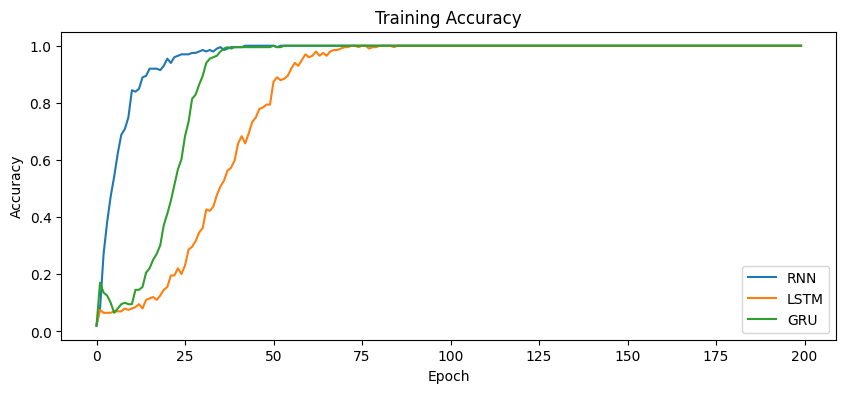

In [34]:
plt.figure(figsize=(10,4))

plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 📉 Compare Training Loss

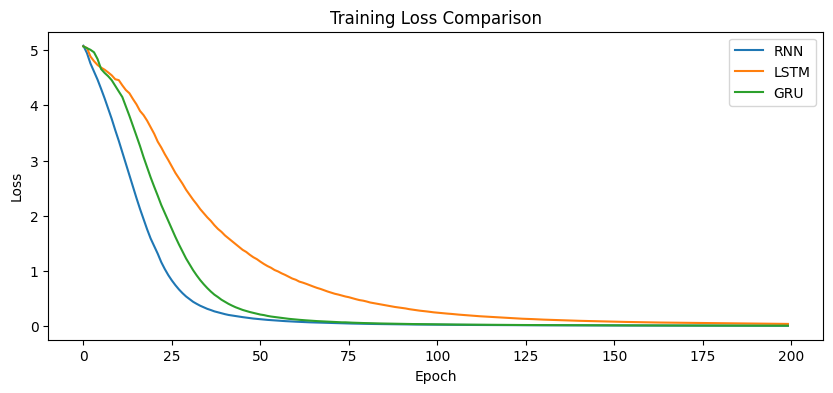

In [35]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# NO OF PARAMETERS

In [36]:
rnn_model.summary()
print("-"*80)

lstm_model.summary()
print("-"*80)

gru_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 122, 128)       │        20,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 159)            │        20,511 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,279 (864.38 KB)

 Trainable params: 73,759 (288.12 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 122, 128)       │        20,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 159)            │        20,511 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,807 (1.60 MB)

 Trainable params: 139,935 (546.62 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 279,872 (1.07 MB)

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [37]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [39]:
print("RNN :", generate_text(rnn_model, "The company", 10))
print("LSTM:", generate_text(lstm_model, "The company", 10))
print("GRU :", generate_text(gru_model, "The company", 10))

RNN : The company to mid 2000s the company invested over a the dollars
LSTM: The company corporation is an american multinational technology in california the company
GRU : The company develops over a broad range compute intensive applications as a


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**